# RQ3: Sentiment Progression Analysis

### Hypothesis:
### AI art posts will show a steeper negative sentiment slope over comment position (1-50) compared to matched human art posts.

## **Step 0: Installations**

In [2]:
!pip install -q transformers torch datasets emoji deep-translator langdetect sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 28.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.4 MB/s eta 0:00:00


## **Step 1: Imports and global constants**

In [6]:
import warnings
warnings.filterwarnings('ignore')
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from scipy.stats import wilcoxon, linregress

SCORES_CSV = 'rq3_scores_v3.csv'
HF_DATASET = 'sparklessszzz/InstaArt-HumanAI'
HUMAN_COLOR = '#1565C0'
AI_COLOR    = '#C62828'

## **Step 2: Load Dataset**

In [3]:
# utility functions
def get_comment_cols(df):
    cols = [c for c in df.columns if isinstance(c,str) and c.startswith('comment_')]
    return sorted(cols, key=lambda x: int(x.split('_')[1]))

In [ ]:
print('Loading datset from HuggingFace...')
posts_df = load_dataset(HF_DATASET, 'posts_primary',       split='train').to_pandas()
hc_df    = load_dataset(HF_DATASET, 'human_comments',      split='train').to_pandas()
hd_df    = load_dataset(HF_DATASET, 'human_comment_dates', split='train').to_pandas()
ac_df    = load_dataset(HF_DATASET, 'ai_comments',         split='train').to_pandas()
ad_df    = load_dataset(HF_DATASET, 'ai_comment_dates',    split='train').to_pandas()

# setting post_id as index of the dataframe
for df in [hc_df, hd_df, ac_df, ad_df]:
    if 'post_id' in df.columns:
        df.set_index('post_id', inplace=True)


# collect Human and AI post IDs
pairs_meta = posts_df[['human_post_id','ai_post_id']].dropna().reset_index(drop=True)
human_ids  = pairs_meta['human_post_id'].tolist()
ai_ids     = pairs_meta['ai_post_id'].tolist()

# gather corresponding Human and AI comments
H_COLS = get_comment_cols(hc_df)
A_COLS = get_comment_cols(ac_df)

print(f'Matched pairs: {len(pairs_meta)}')
print(f'Human comment cols: {len(H_COLS)}  |  AI comment cols: {len(A_COLS)}')

Loading from HuggingFace...


Generating train split:   0%|          | 0/40 [00:00<?, ? examples/s]

Human_Comments_Data.csv:   0%|          | 0.00/64.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40 [00:00<?, ? examples/s]

Human_CommentDate.csv:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

...

AI_Comments_Data.csv:   0%|          | 0.00/46.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40 [00:00<?, ? examples/s]

AI_CommentDate_Data.csv:   0%|          | 0.00/28.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40 [00:00<?, ? examples/s]

Matched pairs: 40
Human comment cols: 50  |  AI comment cols: 50


## **Step 3: Load Models**

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from langdetect import detect, LangDetectException
import emoji as emoji_lib
from deep_translator import GoogleTranslator

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

SENTIMENT_MODEL = 'cardiffnlp/twitter-xlm-roberta-base-sentiment'
print('Loading XLM-RoBERTa sentiment model...')
sent_tok   = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
sent_model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL)
sent_model.eval().to(device)
print('Sentiment model ready.')

Device: cuda
Loading XLM-RoBERTa sentiment model...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

## **Step 4: Data Preprocessing**

In [8]:
# utilities for data preprocessing

# Emoji to English text converter
def emojis_to_text(text):
    """
    Replace every emoji with its CLDR English description.
    Example: '❤️' with 'red heart'
    """
    return emoji_lib.replace_emoji(
        text, replace=lambda s, data: f' {data["en"]} ')

# Non-Engish to English text translator
def translate_to_english(text):
    try:
        lang = detect(str(text))
    except LangDetectException:
        lang = 'en'
    if lang == 'en':
        return text
    try:
        result = GoogleTranslator(source='auto', target='en').translate(text)
        return result if result else text
    except Exception:
        return text

# Combining above 2 utilities to get the pre-processed comments data
def preprocess(text):
    if not isinstance(text, str) or not text.strip():
        return None
    text = emojis_to_text(text)       # step 1: emoji → text
    text = translate_to_english(text) # step 2: translate
    text = re.sub(r'\s+', ' ', text).strip()
    return text if text else None

# Score the sentiment of the comment
def score_text(text):
    if not isinstance(text, str) or not text.strip():
        return np.nan
    enc = sent_tok(text, return_tensors='pt', truncation=True,
                   max_length=128, padding=True).to(device)
    with torch.no_grad():
        probs = torch.softmax(
            sent_model(**enc).logits, dim=-1
        ).squeeze().cpu().numpy()
    return float(-probs[0] + probs[2])  # [-1, +1]

In [ ]:

# Preprocessed data generator
def build_flat(comment_df, date_df, cols, condition):
    rows = []
    for post_id in comment_df.index:
        if post_id not in date_df.index:
            continue
        pairs = []
        for col in cols:
            text = comment_df.loc[post_id, col] if col in comment_df.columns else np.nan
            ts   = pd.to_datetime(
                date_df.loc[post_id, col] if col in date_df.columns else pd.NaT,
                errors='coerce')
            if isinstance(text, str) and text.strip() and pd.notna(ts):
                pairs.append((ts, text))
        pairs.sort(key=lambda x: x[0])  # sort oldest → newest
        for i, (ts, text) in enumerate(pairs[:50], start=1):
            rows.append({'condition': condition, 'post_id': post_id,
                         'position': i, 'timestamp': ts, 'raw_text': text})
    return pd.DataFrame(rows)

print('Building comment tables...')
all_comments = pd.concat([
    build_flat(hc_df, hd_df, H_COLS, 'human'),
    build_flat(ac_df, ad_df, A_COLS, 'ai'),
], ignore_index=True)
print(f'Total: {len(all_comments)} comments  '
      f'({(all_comments.condition=="human").sum()} human, '
      f'{(all_comments.condition=="ai").sum()} AI)')

# utility to run the cell multiple times
already_done = set()
if os.path.exists(SCORES_CSV):
    done_df = pd.read_csv(SCORES_CSV)
    already_done = set(zip(done_df.post_id, done_df.position, done_df.condition))
    print(f'Resuming — {len(already_done)} done, '
          f'{len(all_comments)-len(already_done)} remaining')

to_process = all_comments[
    ~all_comments.apply(
        lambda r: (r.post_id, r.position, r.condition) in already_done,
        axis=1)
].reset_index(drop=True)

buffer = []
for i, row in enumerate(to_process.itertuples(), start=1):
    clean     = preprocess(row.raw_text)
    sentiment = score_text(clean) if clean else np.nan
    buffer.append({
        'condition':      row.condition,
        'post_id':        row.post_id,
        'position':       row.position,
        'timestamp':      row.timestamp,
        'raw_text':       row.raw_text,
        'processed_text': clean,
        'sentiment':      sentiment,
    })
    if i % 100 == 0:
        pd.DataFrame(buffer).to_csv(
            SCORES_CSV, mode='a',
            header=not os.path.exists(SCORES_CSV), index=False)
        buffer = []
        print(f'  Checkpoint {len(already_done)+i}/{len(all_comments)}', end='\r')

if buffer:
    pd.DataFrame(buffer).to_csv(
        SCORES_CSV, mode='a',
        header=not os.path.exists(SCORES_CSV), index=False)

print(f'\nDone. Scores saved to {SCORES_CSV}')

Building comment tables...
Total: 2760 comments  (1526 human, 1234 AI)


## **Step 5: Process the Data**

In [ ]:
# Load scores, compute slopes, build pairs table
scores = pd.read_csv(SCORES_CSV)
print(f'Loaded {len(scores)} scored comments')

def get_series(condition):
    """Dict: {post_id: DataFrame with columns [position, sentiment]}"""
    out = {}
    sub = scores[scores.condition == condition]
    for pid, grp in sub.groupby('post_id'):
        grp = grp.dropna(subset=['sentiment']).sort_values('position')
        if len(grp) >= 3:
            out[pid] = grp[['position','sentiment']].reset_index(drop=True)
    return out

human_series = get_series('human')
ai_series    = get_series('ai')
print(f'Valid series — Human: {len(human_series)}  AI: {len(ai_series)}')

def get_slope_intercept(series_df):
    x = series_df['position'].values.astype(float)
    y = series_df['sentiment'].values.astype(float)
    s, intercept, *_ = linregress(x, y)
    return s, intercept

paired = []
for pn, (h_id, a_id) in enumerate(zip(human_ids, ai_ids), start=1):
    if h_id in human_series and a_id in ai_series:
        hs, hi = get_slope_intercept(human_series[h_id])
        as_, ai_int = get_slope_intercept(ai_series[a_id])
        paired.append({
            'pair_num':    pn,
            'human_id':    h_id,
            'ai_id':       a_id,
            'human_slope': hs,
            'ai_slope':    as_,
            'human_int':   hi,
            'ai_int':      ai_int,
            'slope_diff':  as_ - hs,
        })

pairs = pd.DataFrame(paired)
pairs.to_csv('rq2_per_post_slopes_v3.csv', index=False)

if not pairs.empty:
    hv = pairs['human_slope'].values
    av = pairs['ai_slope'].values
    print(f'Valid matched pairs: {len(pairs)}')
else:
    hv = np.array([])
    av = np.array([])
    print('No valid matched pairs found for slope calculation.')


Loaded 2760 scored comments
Valid series — Human: 39  AI: 38
Valid matched pairs: 37


## **Step 6: Plots and visualizations**

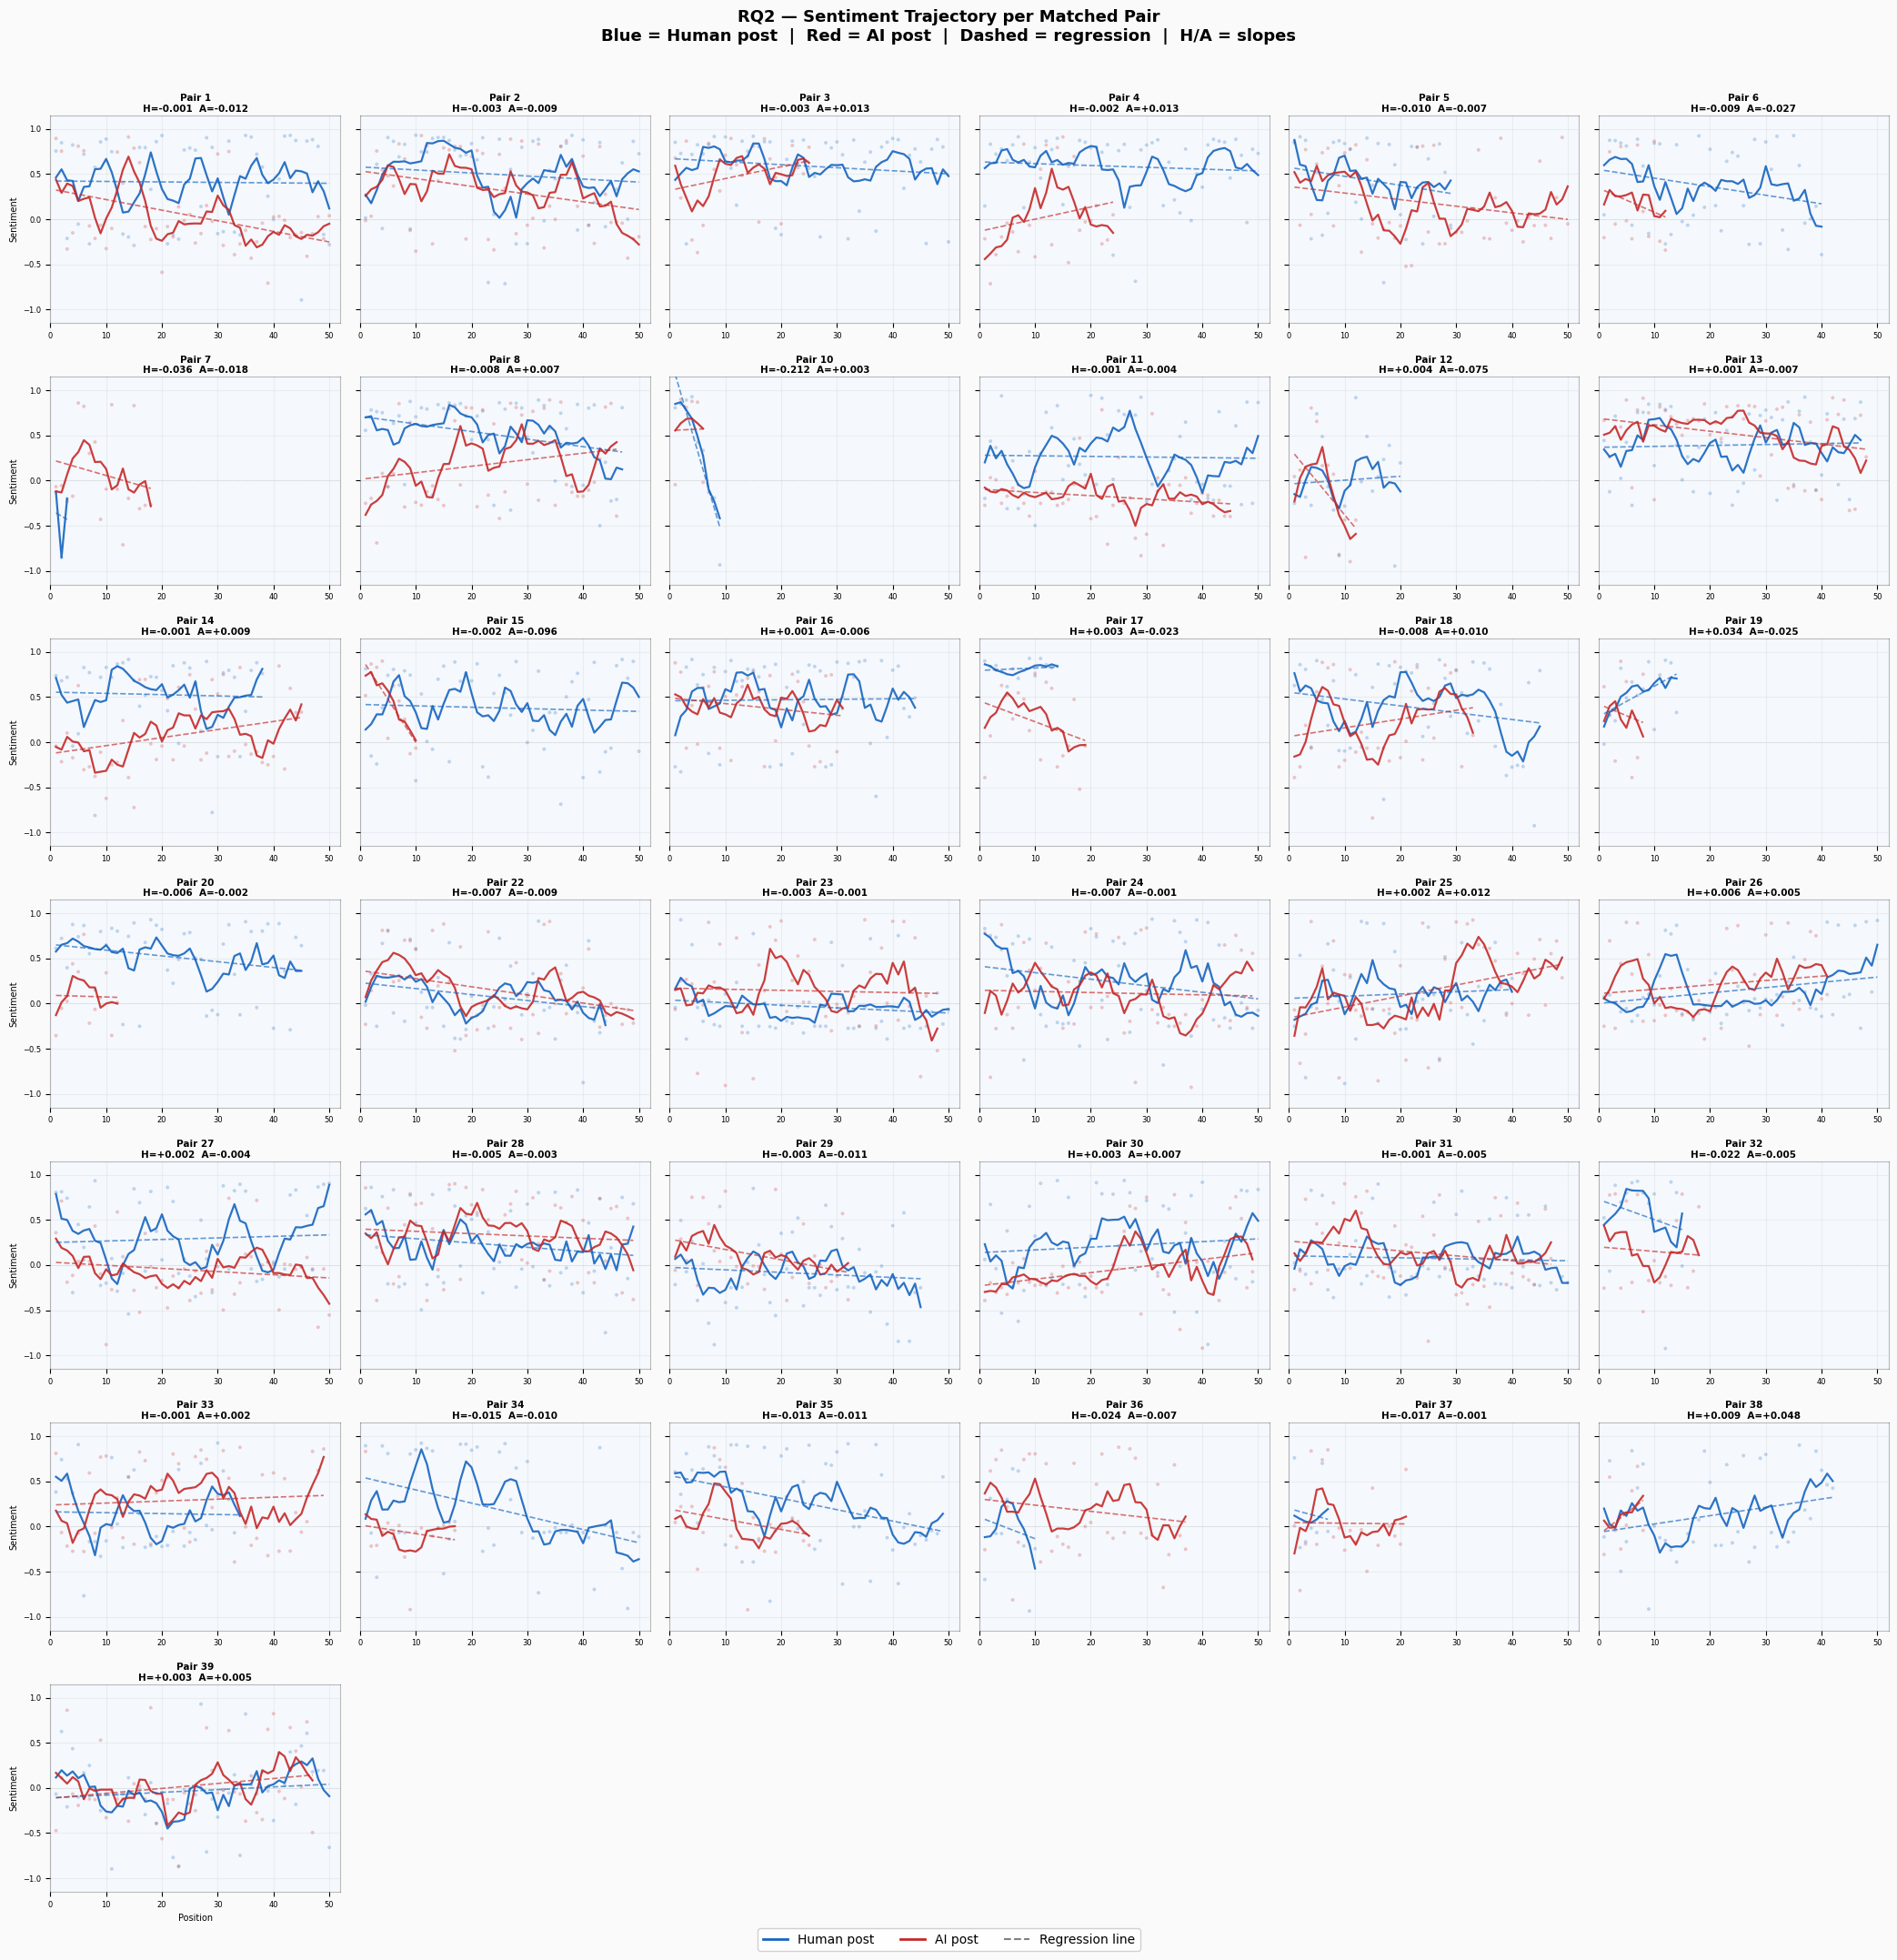

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded rq2_pair_plots/rq2_all_pairs_grid.png
✓ Grid of 37 pairs saved to rq2_pair_plots/rq2_all_pairs_grid.png


In [ ]:
# 40 Individual Pair Plots
# x-axis = comment position (1 = earliest by real timestamp)
# Blue = human post  &  Red = AI post
# Legend: Dots = raw sentiment  |  Solid = smoothed  |  Dashed = regression

os.makedirs('rq2_pair_plots', exist_ok=True)

def smooth(arr, w=5):
    return pd.Series(arr).rolling(w, min_periods=1, center=True).mean().values

n_pairs = len(pairs)
ncols   = 6
nrows   = int(np.ceil(n_pairs / ncols))   # 7 rows × 6 cols = 42 panels, last few hidden

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 3.5, nrows * 3.0),
                          sharex=False, sharey=True)
fig.patch.set_facecolor('#FAFAFA')
axes_flat = axes.flatten()

for idx, (_, row) in enumerate(pairs.iterrows()):
    ax    = axes_flat[idx]
    h_id  = row['human_id']
    a_id  = row['ai_id']
    pnum  = int(row['pair_num'])

    ax.set_facecolor('#F5F8FC')

    for series, color, slope, intercept in [
        (human_series.get(h_id), HUMAN_COLOR, row['human_slope'], row['human_int']),
        (ai_series.get(a_id),    AI_COLOR,    row['ai_slope'],    row['ai_int']),
    ]:
        if series is None or len(series) < 2:
            continue
        x = series['position'].values
        y = series['sentiment'].values

        # Raw dots
        ax.scatter(x, y, color=color, alpha=0.25, s=8,
                   zorder=3, edgecolors='none')
        # Smoothed line
        y_smooth = smooth(y) if len(x) >= 5 else y
        ax.plot(x, y_smooth, color=color, lw=1.6, alpha=0.9, zorder=4)
        # Regression line
        xl = np.array([x.min(), x.max()])
        ax.plot(xl, slope * xl + intercept,
                color=color, lw=1.2, ls='--', alpha=0.65, zorder=5)

    ax.axhline(0, color='#aaa', lw=0.6, ls=':', alpha=0.5)
    ax.set_xlim(0, 52)
    ax.set_ylim(-1.15, 1.15)
    ax.set_title(
        f'Pair {pnum}\n'
        f'H={row["human_slope"]:+.3f}  A={row["ai_slope"]:+.3f}',
        fontsize=7.5, pad=3, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.15)
    for sp in ax.spines.values():
        sp.set_alpha(0.25)

    # x-label only on bottom row
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Position', fontsize=7)
    # y-label only on leftmost col
    if idx % ncols == 0:
        ax.set_ylabel('Sentiment', fontsize=7)

# Hide unused panels
for idx in range(n_pairs, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=HUMAN_COLOR, lw=2,   label='Human post'),
    Line2D([0], [0], color=AI_COLOR,    lw=2,   label='AI post'),
    Line2D([0], [0], color='gray',      lw=1.5,
           ls='--', label='Regression line'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=10, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    'RQ2 — Sentiment Trajectory per Matched Pair\n'
    'Blue = Human post  |  Red = AI post  |  '
    'Dashed = regression  |  H/A = slopes',
    fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout(pad=1.2)
out_path = 'rq2_pair_plots/rq2_all_pairs_grid.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight')
plt.show()
plt.close()

from google.colab import files
files.download(out_path)
print(f'Downloaded {out_path}')

print(f'Grid of {n_pairs} pairs saved to {out_path}')

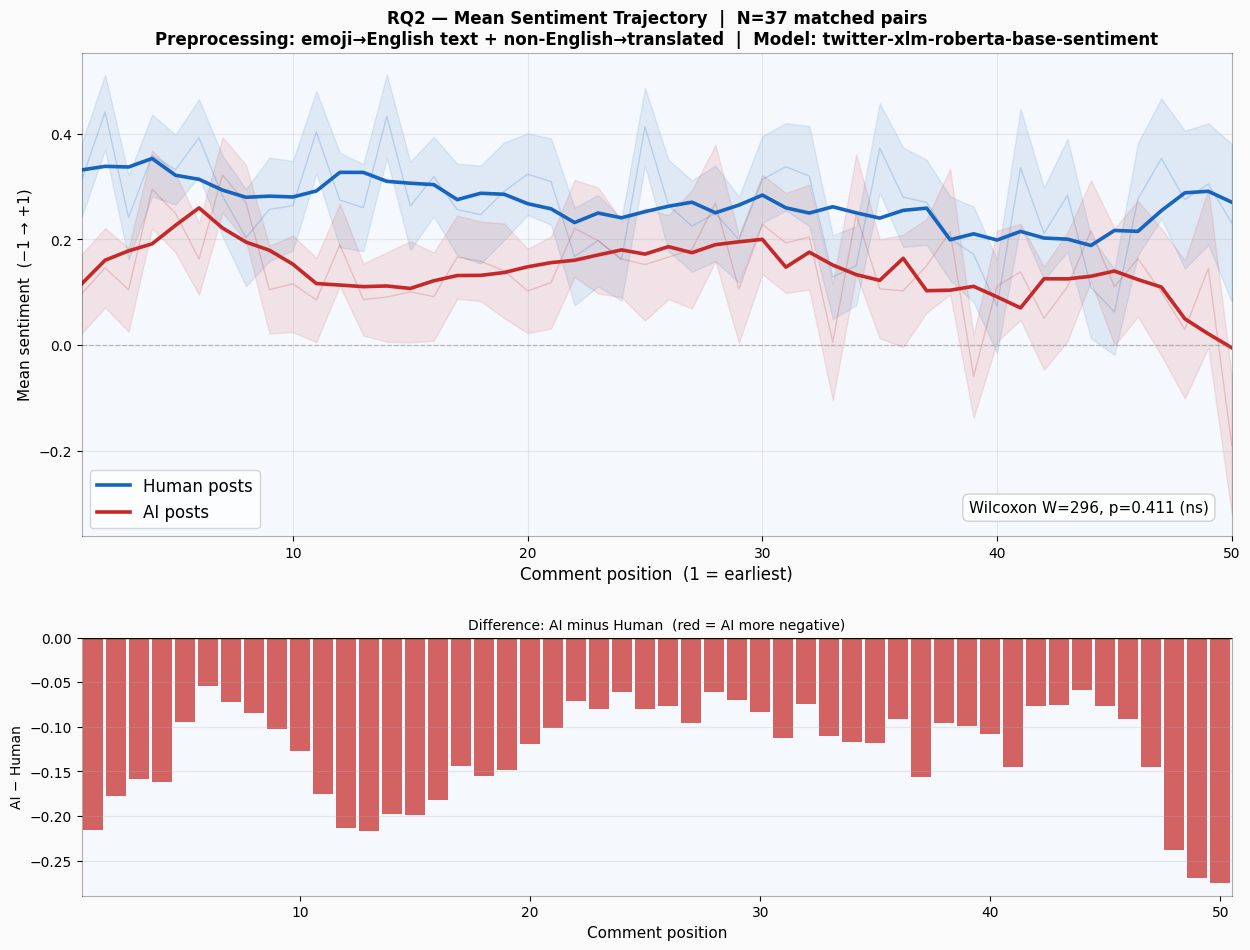

Saved rq2_overall_trajectory.png


In [ ]:
# Overall Mean Trajectory + Difference Bar

positions = list(range(1, 51))

def mean_sem_at(condition):
    sub = scores[scores.condition == condition]
    means, sems = [], []
    for p in positions:
        vals = sub[sub.position == p]['sentiment'].dropna()
        means.append(vals.mean() if len(vals) > 0 else np.nan)
        sems.append(vals.sem()   if len(vals) > 1 else 0)
    return np.array(means), np.array(sems)

hm, hs   = mean_sem_at('human')
am, as_  = mean_sem_at('ai')
x        = np.array(positions)
stat, p  = wilcoxon(hv, av, alternative='two-sided')

fig, axes = plt.subplots(2, 1, figsize=(13, 10),
                          gridspec_kw={'height_ratios': [3, 1.6]})
fig.patch.set_facecolor('#FAFAFA')

ax = axes[0]
ax.set_facecolor('#F5F8FC')
ax.plot(x, hm,         color=HUMAN_COLOR, alpha=0.2, lw=1)
ax.plot(x, am,         color=AI_COLOR,    alpha=0.2, lw=1)
ax.plot(x, smooth(hm), color=HUMAN_COLOR, lw=2.6, label='Human posts')
ax.plot(x, smooth(am), color=AI_COLOR,    lw=2.6, label='AI posts')
ax.fill_between(x, hm-hs, hm+hs,   color=HUMAN_COLOR, alpha=0.10)
ax.fill_between(x, am-as_, am+as_, color=AI_COLOR,    alpha=0.10)
ax.axhline(0, color='#888', lw=0.9, ls='--', alpha=0.5)
ax.text(0.98, 0.05,
        f'Wilcoxon W={stat:.0f}, p={p:.3f} '
        f'{"*" if p<0.05 else "(ns)"}',
        transform=ax.transAxes, ha='right', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCC', alpha=0.9))
ax.set_xlabel('Comment position  (1 = earliest)', fontsize=12)
ax.set_ylabel('Mean sentiment  (−1 → +1)', fontsize=11)
ax.set_title(
    f'RQ2 — Mean Sentiment Trajectory  |  N={len(pairs)} matched pairs\n'
    f'Preprocessing: emoji→English text + non-English→translated  |  '
    f'Model: twitter-xlm-roberta-base-sentiment',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=12); ax.set_xlim(1, 50); ax.grid(True, alpha=0.25)
for sp in ax.spines.values(): sp.set_alpha(0.3)

ax2 = axes[1]
ax2.set_facecolor('#F5F8FC')
diff_s = smooth(am - hm)
ax2.bar(x, diff_s,
        color=[AI_COLOR if d < 0 else HUMAN_COLOR for d in diff_s],
        alpha=0.72, width=0.88)
ax2.axhline(0, color='black', lw=1.0)
ax2.set_xlabel('Comment position', fontsize=11)
ax2.set_ylabel('AI − Human', fontsize=10)
ax2.set_title('Difference: AI minus Human  (red = AI more negative)',
              fontsize=10)
ax2.set_xlim(0.5, 50.5); ax2.grid(True, axis='y', alpha=0.25)
for sp in ax2.spines.values(): sp.set_alpha(0.3)

plt.tight_layout(pad=2.5)
plt.savefig('rq2_overall_trajectory.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved rq2_overall_trajectory.png')

# **Key Findings**

- **No negativity pile-on**: Both human-made and AI-generated art posts maintained consistently positive comment sentiment across all 50 comments across 40 post pairs, contradicting our hypothesis of escalating negativity over time.

- **Human art warmer reception**: Human art elicited slightly more emotionally intense, admiring responses (e.g., "this literally made me stop scrolling") compared to AI art's more reserved positivity (e.g., "wow cool").

- **AI excels in fantasy**: AI art matched or exceeded human sentiment for fantastical subjects (aliens, mythology, cosmic scenes) where real-world authenticity critiques don't apply, demonstrating that subject matter outweighs creation method.
